Will the removal of level crossings and related transport improvements along the Upfield line drive faster house price growth in treated suburbs compared with untreated suburbs?

Focusing on three main variables:
- Suburb
- House price
- Population density

# Visualisations

The suburbs will be separated into two groups, "Treated" and "Untreated" based on their distance to the closest LXRP site.

In [33]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

YEARS = list(range(2015, 2025))
YEAR_STR = [str(y) for y in YEARS]

project_root = Path.cwd()
if not (project_root / "data" / "clean").exists():
    project_root = project_root.parent

clean = project_root / "data" / "clean"
price_wide = pd.read_csv(clean / "suburbs_house_prices_2015_2024_wide_complete.csv")
price_wide["Suburb"] = price_wide["Suburb"].astype(str).str.strip().str.title()
price_wide[YEAR_STR] = price_wide[YEAR_STR].apply(pd.to_numeric, errors="coerce")

log_price_wide = price_wide.copy()
log_price_wide[YEAR_STR] = np.log(log_price_wide[YEAR_STR])

density_long = pd.read_csv(clean / "requested_suburbs_density_2015_2024_long.csv").rename(
    columns={"requested_suburb": "Suburb", "year": "Year", "density": "Density"}
)
density_long["Suburb"] = density_long["Suburb"].astype(str).str.strip().str.title()
density_long["Year"] = pd.to_numeric(density_long["Year"], errors="coerce").astype(int)
density_long["Density"] = pd.to_numeric(density_long["Density"], errors="coerce")

# Reconstruct a wide density table so the chart cells can work from the cleaned files.
density_wide = (
    density_long.pivot(index="Suburb", columns="Year", values="Density")
    .reindex(columns=YEARS)
    .reset_index()
)
density_wide.columns = ["Suburb"] + YEAR_STR

treated_suburbs = [
    "Chelsea", "Laverton", "Ringwood", "Mentone", "Preston", "Blackburn",
    "Beaconsfield", "Essendon", "Glen Iris", "Cranbourne", "Campbellfield",
    "Pakenham", "Lilydale", "Bentleigh", "Clayton", "Noble Park", "Cheltenham",
    "Werribee", "Berwick", "Croydon", "Noble Park", "Edithvale", "Williamstown",
    "Ardeer", "St Albans", "Sunbury", "Glenroy", "Alphington", "Carnegie",
    "Hallam", "Mitcham", "Reservoir", "Coburg", "Brunswick", "Bundoora",
]

untreated_suburbs = [
    "Doncaster", "Doncaster East", "Donvale", "Templestowe", "Templestowe Lower",
    "Warrandyte", "Wonga Park", "Park Orchards", "Bulleen", "Rowville",
    "Lysterfield", "Scoresby", "Knoxfield", "Wantirna", "Wantirna South",
    "The Basin", "Endeavour Hills", "Doveton", "Greenvale", "Gladstone Park",
    "Westmeadows", "Tullamarine", "Keilor East",
]

treated_df = log_price_wide[log_price_wide["Suburb"].isin(treated_suburbs)].copy()
untreated_df = log_price_wide[log_price_wide["Suburb"].isin(untreated_suburbs)].copy()
all_suburbs_df = log_price_wide.copy()

price_long = log_price_wide.melt(
    id_vars="Suburb",
    value_vars=YEAR_STR,
    var_name="Year",
    value_name="log_HousePrice",
)
price_long["Suburb"] = price_long["Suburb"].astype(str).str.strip().str.title()
price_long["Year"] = pd.to_numeric(price_long["Year"], errors="coerce").astype(int)
price_long["log_HousePrice"] = pd.to_numeric(price_long["log_HousePrice"], errors="coerce")

price_grouped_yearly = price_long.groupby(["Year", "Suburb"], as_index=False).agg(
    log_HousePrice=("log_HousePrice", "median"),
)
price_grouped_yearly["Group"] = "Unclassified"
price_grouped_yearly.loc[price_grouped_yearly["Suburb"].isin(treated_suburbs), "Group"] = "Treated"
price_grouped_yearly.loc[price_grouped_yearly["Suburb"].isin(untreated_suburbs), "Group"] = "Untreated"
price_grouped_yearly = price_grouped_yearly[price_grouped_yearly["Group"].isin(["Treated", "Untreated"])].copy()
price_grouped_yearly = price_grouped_yearly.groupby(["Year", "Group"], as_index=False).agg(
    log_HousePriceMedian=("log_HousePrice", "median"),
)

panel = price_long.merge(density_long[["Suburb", "Year", "Density"]], on=["Suburb", "Year"], how="inner")

panel["Group"] = "Unclassified"
panel.loc[panel["Suburb"].isin(treated_suburbs), "Group"] = "Treated"
panel.loc[panel["Suburb"].isin(untreated_suburbs), "Group"] = "Untreated"
panel = panel[panel["Group"].isin(["Treated", "Untreated"])].copy()

panel["log_Density"] = np.log(panel["Density"].clip(lower=1e-9))

grouped_yearly = panel.groupby(["Year", "Group"], as_index=False).agg(
    log_HousePriceMedian=("log_HousePrice", "median"),
    DensityMedian=("Density", "median"),
)


**Median house price by suburb (2015 to 2024)**

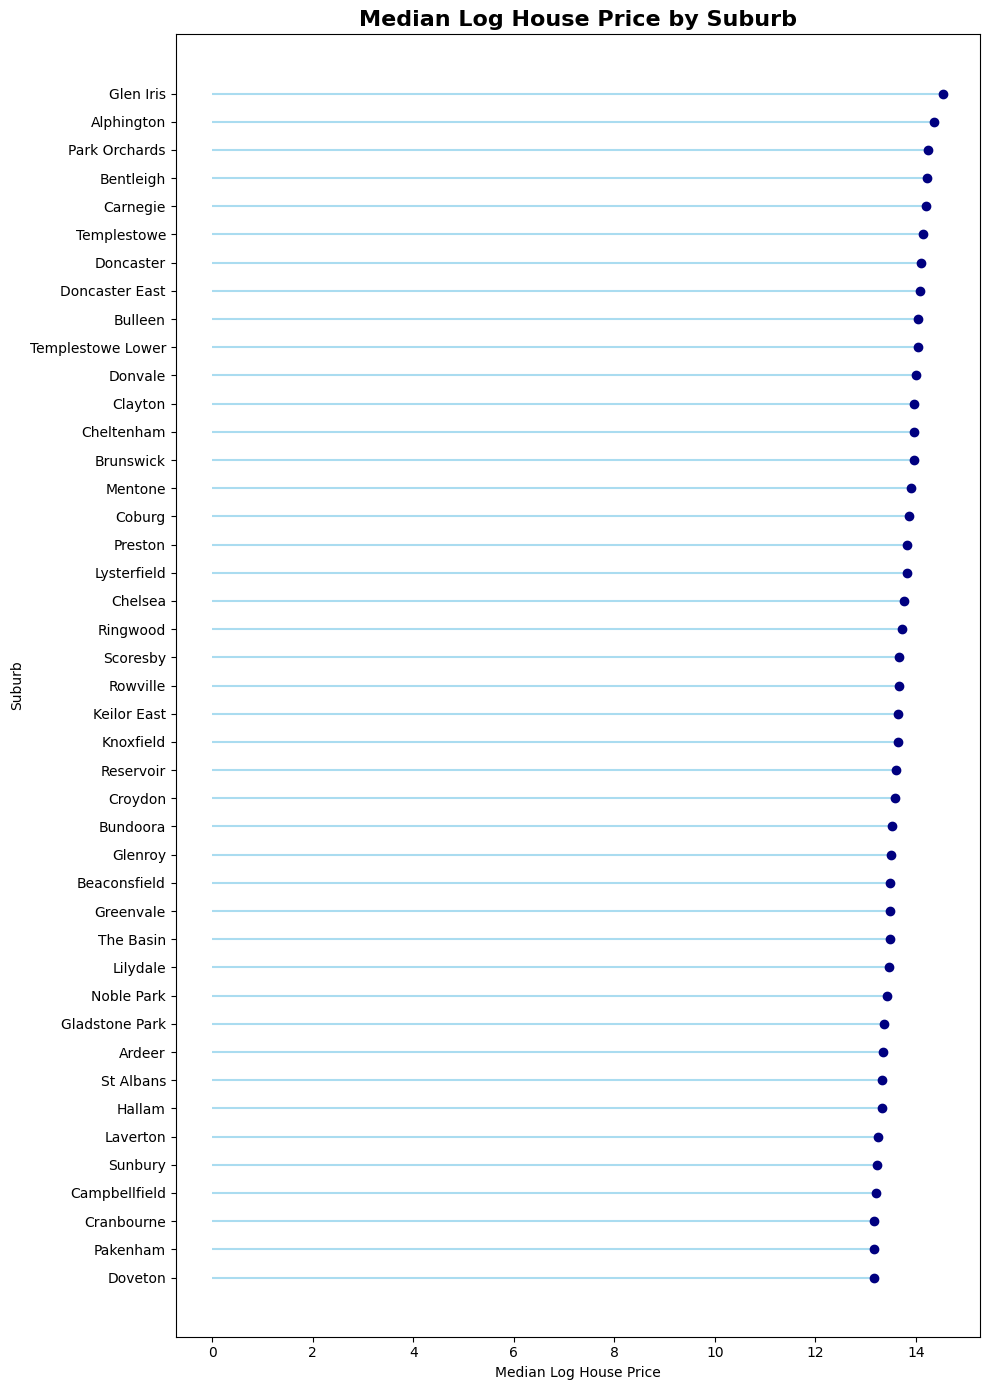

In [21]:
eda = pd.concat([adjacent_df, faraway_df], ignore_index=True)

eda = eda.melt(
    id_vars="Suburb",
    var_name="Year",
    value_name="log_HousePrice"
)

eda["log_HousePrice"] = pd.to_numeric(eda["log_HousePrice"], errors="coerce")
eda = eda.dropna()

import matplotlib.pyplot as plt

# Median log house price by suburb
suburb_median = (
    eda.groupby("Suburb", as_index=False)["log_HousePrice"]
    .median()
    .sort_values("log_HousePrice", ascending=True)
)

plt.figure(figsize=(10,14))

# Lines
plt.hlines(
    y=suburb_median["Suburb"],
    xmin=0,
    xmax=suburb_median["log_HousePrice"],
    color="skyblue",
    alpha=0.7
)

# Dots
plt.plot(
    suburb_median["log_HousePrice"],
    suburb_median["Suburb"],
    "o",
    color="navy"
)

plt.title("Median Log House Price by Suburb", fontsize=16, weight="bold")
plt.xlabel("Median Log House Price")
plt.ylabel("Suburb")
plt.tight_layout()
plt.show()

This ranked lollipop chart compares the median log house price of each suburb across 2015-2024. It shows which suburbs have higher or lower baseline price levels before we compare treated and untreated groups. That matters for the research question because faster growth along the nearest LXRP site is easier to interpret if we first understand the starting price differences across suburbs.

**Box & Whisker plot (treated and untreated suburbs with their median house prices)**

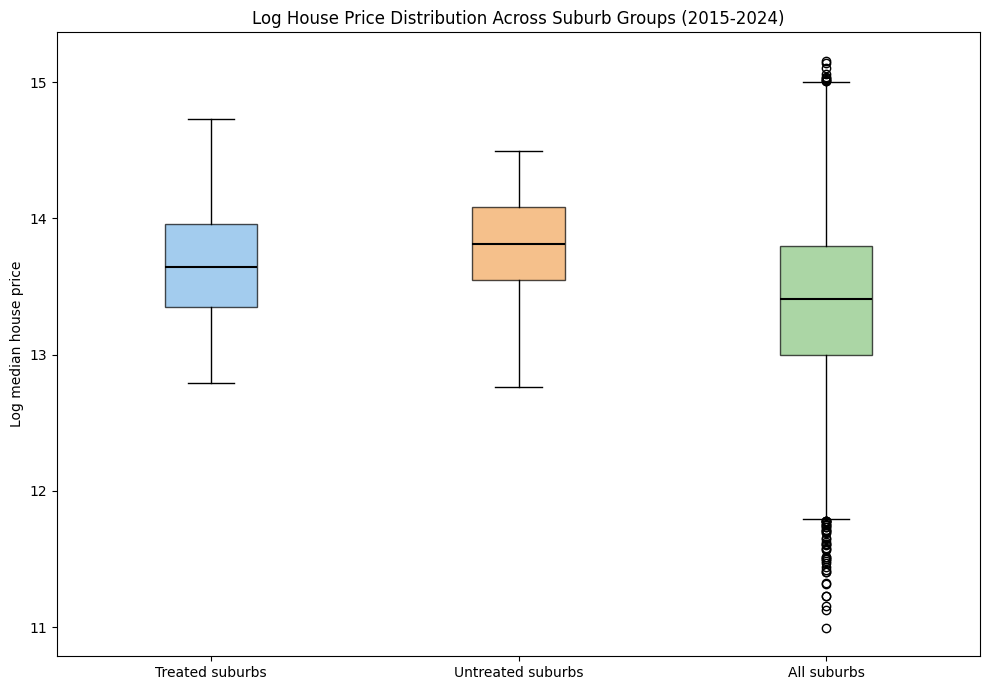

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve project root reliably whether or not earlier cells were run.
if "project_root" in globals():
    root = Path(project_root)
else:
    root = Path.cwd()

year_cols = YEAR_STR

# Stack each suburb group into a single year-level distribution, using log prices.
def values_from_wide(df):
    values = df[year_cols].apply(pd.to_numeric, errors="coerce").to_numpy().ravel()
    return pd.Series(values).dropna().values

treated_values = values_from_wide(treated_df)
untreated_values = values_from_wide(untreated_df)
all_values = values_from_wide(all_suburbs_df)

fig, ax = plt.subplots(figsize=(10, 7))
box = ax.boxplot(
    [treated_values, untreated_values, all_values],
    tick_labels=["Treated suburbs", "Untreated suburbs", "All suburbs"],
    showfliers=True,
    patch_artist=True,
)

colors = ["#7db7e8", "#f2a65a", "#88c57f"]
for patch, color in zip(box["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in box["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

ax.set_ylabel("Log median house price")
ax.set_title("Log House Price Distribution Across Suburb Groups (2015-2024)")
plt.tight_layout()
plt.show()

This boxplot compares the distribution of log annual house prices for treated suburbs, untreated suburbs, and all suburbs on the same scale.

Showing the three groups together makes it easier to compare the spread and level of prices after the suburb counts were updated in the cleaned data.

This box-and-whisker plot summarizes the distribution of yearly median house prices for faraway suburbs over 2015-2024. It provides the comparison group for suburbs less likely to be affected by the LXRP works. Comparing this with the adjacent-group boxplot helps show whether the price pattern near the line is unusually high, low, or more volatile.

**Box and whisker plot for population density across all suburbs**

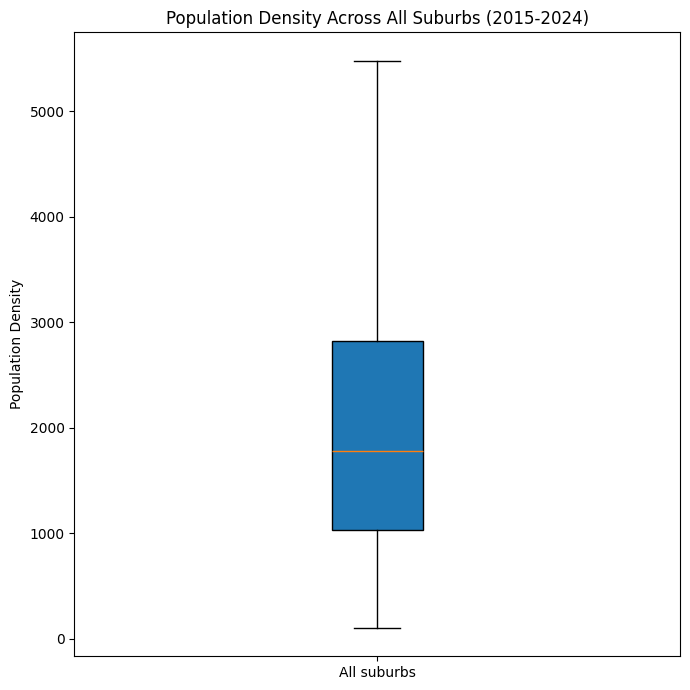

In [13]:
density_cols = [col for col in wide.columns if col not in ["No.", "Suburb"]]
density_values = wide[density_cols].apply(pd.to_numeric, errors="coerce").to_numpy().ravel()
density_values = density_values[~pd.isna(density_values)]

plt.figure(figsize=(7, 7))
plt.boxplot(
    [density_values],
    tick_labels=["All suburbs"],
    vert=True,
    showfliers=False,
    patch_artist=True,
)
plt.title("Population Density Across All Suburbs (2015-2024)")
plt.ylabel("Population Density")
plt.tight_layout()
plt.show()

This boxplot combines all suburb-year density observations (2015-2024) into a single distribution. It shows the overall range of density across the study area, which helps us understand how much variation there is in the places being compared. That matters because population density may help explain why house prices respond differently in adjacent suburbs versus faraway suburbs.

**Time series for overall house price trend by suburb group**

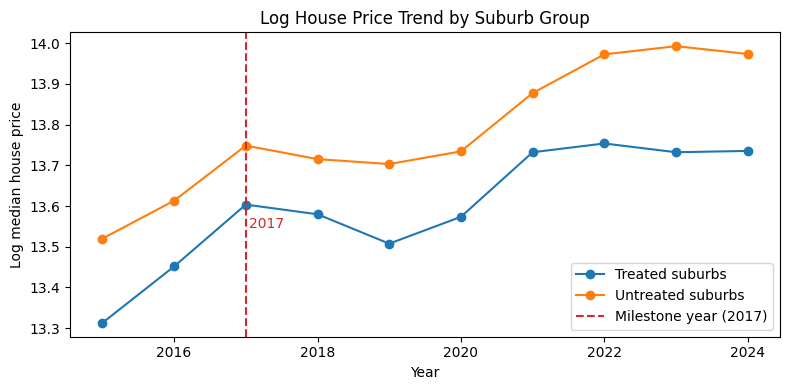

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown

plt.figure(figsize=(8, 4))
for grp in ["Treated", "Untreated"]:
    tmp = price_grouped_yearly[price_grouped_yearly["Group"] == grp]
    if tmp.empty:
        continue
    plt.plot(tmp["Year"], tmp["log_HousePriceMedian"], marker="o", label=f"{grp} suburbs")

plt.axvline(2017, color="#d62728", linestyle="--", linewidth=1.5, label="Milestone year (2017)")
plt.text(
    2017.05,
    price_grouped_yearly["log_HousePriceMedian"].max() * 0.97,
    "2017",
    color="#d62728",
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="left",
)

plt.title("Log House Price Trend by Suburb Group")
plt.xlabel("Year")
plt.ylabel("Log median house price")
plt.legend()
plt.tight_layout()
plt.show()

This graph shows two time-series lines comparing yearly median log house prices for treated versus untreated suburbs.

This is the most direct EDA check for the research question because it shows whether treated suburbs appear to experience faster log house-price growth than untreated suburbs. If the treated line rises more steeply or stays consistently above the untreated line, that would support the idea that proximity to the transport changes is associated with stronger price growth.

**Overall median density trend (all suburbs)**

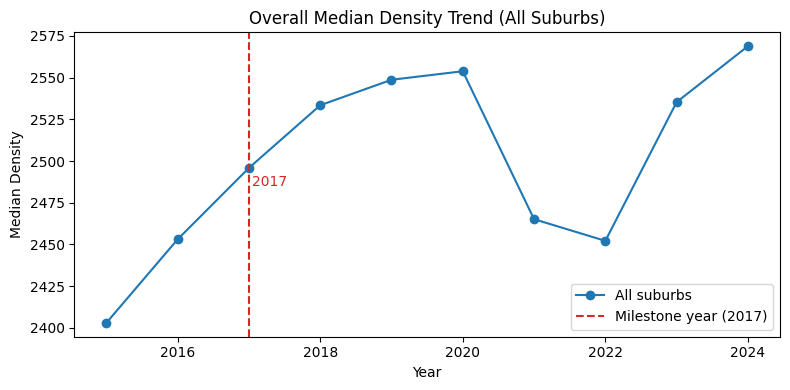

In [34]:
density_all_yearly = (
    density_long.groupby("Year", as_index=False)
    .agg(DensityMedian=("Density", "median"))
)

plt.figure(figsize=(8, 4))
plt.plot(
    density_all_yearly["Year"],
    density_all_yearly["DensityMedian"],
    marker="o",
    label="All suburbs",
)

plt.axvline(2017, color="#d62728", linestyle="--", linewidth=1.5, label="Milestone year (2017)")
plt.text(
    2017.05,
    density_all_yearly["DensityMedian"].max() * 0.97,
    "2017",
    color="#d62728",
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="left",
)

plt.title("Overall Median Density Trend (All Suburbs)")
plt.xlabel("Year")
plt.ylabel("Median Density")
plt.legend()
plt.tight_layout()
plt.show()

This graph shows a single time-series line for yearly median population density across all suburbs.

It provides a simple baseline trend in density over time, with the 2017 milestone shown for reference.

**Scatterplot showing house price vs population density**

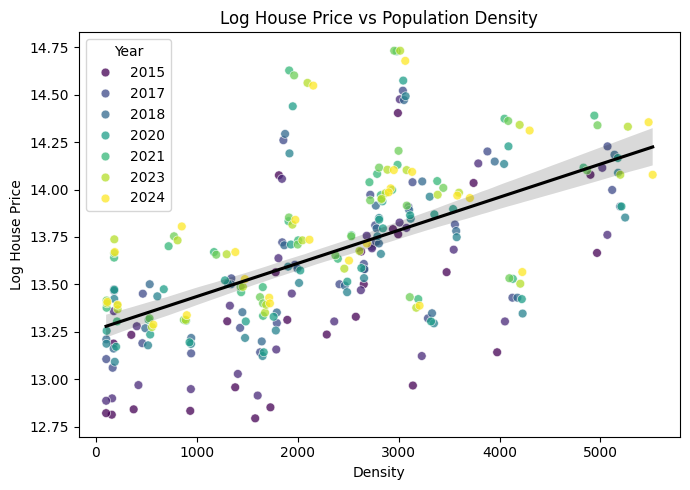

In [17]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=panel, x="Density", y="log_HousePrice", hue="Year", palette="viridis", s=40, alpha=0.75)
sns.regplot(data=panel, x="Density", y="log_HousePrice", scatter=False, color="black")
plt.title("Log House Price vs Population Density")
plt.ylabel("Log House Price")
plt.tight_layout()
plt.show()

Each point is a suburb-year observation with density on the x-axis and log house price on the y-axis, colored by year, plus a fitted trend line.

This checks whether population density is linked to log house prices in a way that could help explain differences between treated and untreated suburbs. It does not answer the research question by itself, but it shows whether density is a useful supporting variable when studying price growth around the nearest LXRP site.

**Correlation heatmap**

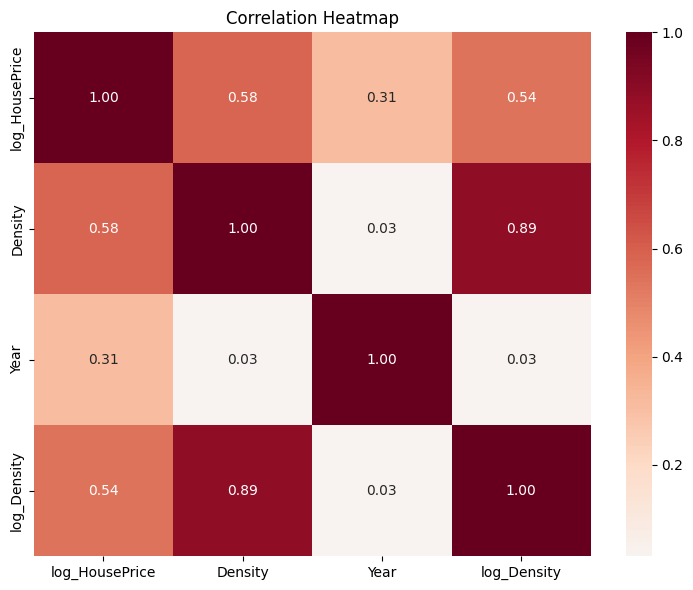

In [18]:
corr_cols = ["log_HousePrice", "Density", "Year", "log_Density"]
corr = panel[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

The heatmap reports pairwise linear correlations among log house price, density, year and log-transformed density.

A Pearson-style correlation is useful here only as a supporting summary, not as the main answer to the research question. Because suburb group is categorical and the key issue is whether treated suburbs grow differently over time, the heatmap mainly helps judge whether density, year, and price move together strongly enough to justify using them in the later comparison.

**Between-suburb vs within-suburb relationship**

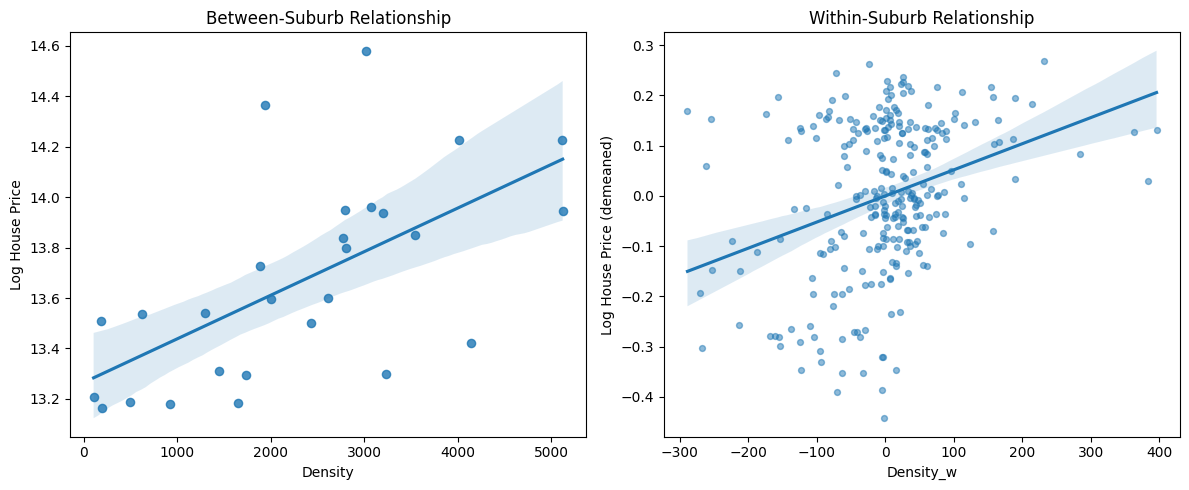

In [19]:
between = panel.groupby("Suburb", as_index=False)[["log_HousePrice", "Density"]].mean()

within = panel.copy()
within["log_HousePrice_w"] = within["log_HousePrice"] - within.groupby("Suburb")["log_HousePrice"].transform("mean")
within["Density_w"] = within["Density"] - within.groupby("Suburb")["Density"].transform("mean")

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=between, x="Density", y="log_HousePrice", ax=axs[0], scatter_kws={"s": 35})
axs[0].set_title("Between-Suburb Relationship")
axs[0].set_ylabel("Log House Price")

sns.regplot(data=within, x="Density_w", y="log_HousePrice_w", ax=axs[1], scatter_kws={"s": 18, "alpha": 0.5})
axs[1].set_title("Within-Suburb Relationship")
axs[1].set_ylabel("Log House Price (demeaned)")

plt.tight_layout()
plt.show()

The left panel uses suburb-level averages (between variation), while the right panel de-means each suburb to isolate within-suburb variation over time.

This is important for the research question because it shows whether the price-density relationship is really about differences between adjacent and faraway suburbs, or about changes within the same suburb over time. If the two slopes differ, then simple pooled comparisons could hide the pattern we care about near the Upfield line.

**OLS diagnostics: residuals vs fitted and Q-Q Plot**

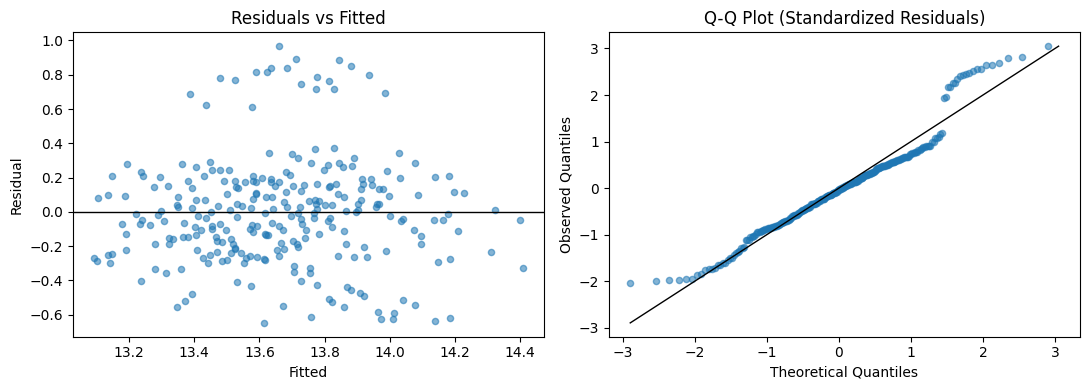

In [20]:
ols = panel[["log_HousePrice", "Density", "Year"]].dropna().copy()

X = np.column_stack([
    np.ones(len(ols)),
    ols["Density"].to_numpy(),
    ols["Year"].to_numpy(),
])
y = ols["log_HousePrice"].to_numpy()

beta, *_ = np.linalg.lstsq(X, y, rcond=None)
fitted = X @ beta
resid = y - fitted

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].scatter(fitted, resid, alpha=0.55, s=20)
axs[0].axhline(0, color="black", lw=1)
axs[0].set_title("Residuals vs Fitted")
axs[0].set_xlabel("Fitted")
axs[0].set_ylabel("Residual")

n = len(resid)
obs = np.sort((resid - resid.mean()) / (resid.std(ddof=1) + 1e-12))
probs = (np.arange(1, n + 1) - 0.5) / n
theor = np.sqrt(2) * np.vectorize(lambda x: np.sign(x) * np.sqrt(np.sqrt((2 / (np.pi * 0.147) + np.log(1 - x * x + 1e-12) / 2) ** 2 - np.log(1 - x * x + 1e-12) / 0.147) - (2 / (np.pi * 0.147) + np.log(1 - x * x + 1e-12) / 2)))(2 * probs - 1)

mn, mx = min(theor.min(), obs.min()), max(theor.max(), obs.max())
axs[1].scatter(theor, obs, alpha=0.55, s=20)
axs[1].plot([mn, mx], [mn, mx], color="black", lw=1)
axs[1].set_title("Q-Q Plot (Standardized Residuals)")
axs[1].set_xlabel("Theoretical Quantiles")
axs[1].set_ylabel("Observed Quantiles")

plt.tight_layout()
plt.show()

The residuals-vs-fitted plot checks nonlinearity and heteroskedasticity, while the Q-Q plot checks whether standardized residuals follow approximate normality.

These diagnostics tell us whether a simple linear relationship is too crude for the research question. If the assumptions are weak, then the apparent adjacent-vs-faraway difference may need a more careful model before we claim anything about faster price growth along the Upfield line.